In [1]:
import numpy as np
import pandas as pd, os, datetime

# Statistical analysis
from scipy import stats
import math
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# plottinng
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import matplotlib.dates as mdates
import folium
from adjustText import adjust_text
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import HTML


In [2]:
df = pd.read_csv('/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_difference_curves.csv')

In [3]:
clust_df = df.query("DUID not in ['CATHROCK']").copy()
piv_df = clust_df.pivot_table(columns='hour', index='DUID', values='median_diff')

In [4]:
def smooth_curve(delta, span=3):
    # Exponential smoothing instead of rolling mean
    return (
        pd.Series(delta)
        .ewm(span=span, adjust=False)  # or use alpha=... if you prefer
        .mean()
        .to_numpy()
    )

df_smooth = piv_df.apply(
    lambda row: smooth_curve(row.values, span=3),
    axis=1,
    result_type="expand",
)
# df_smooth=piv_df

In [5]:
# Use PCA on smoothed curves for clustering
X = df_smooth.values

# Scale curves across hours
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA (retain 95% of variance)
pca = PCA(n_components=0.95, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("PCA components:", X_pca.shape[1])

PCA components: 4


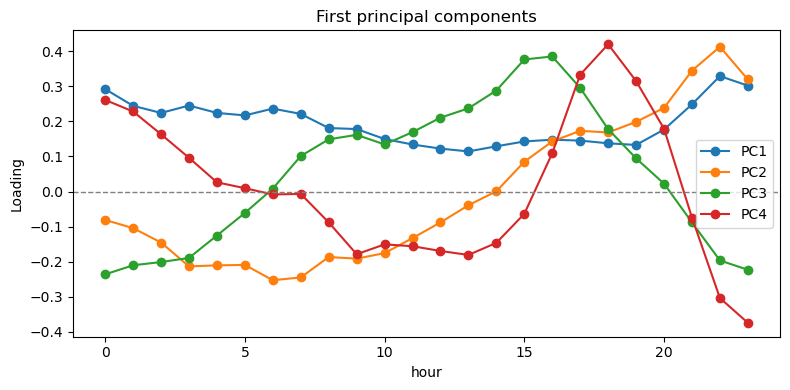

In [6]:
# Plot principal component loadings across hour of day
components = pca.components_

# Number of components and corresponding hour axis
n_components = components.shape[0]
hours = df_smooth.columns.to_numpy().astype(float)

# Plot the first few components (e.g. up to 3)
n_to_plot = min(7, n_components)
plt.figure(figsize=(8, 4))
for i in range(n_to_plot):
    plt.plot(hours, components[i], marker="o", label=f"PC{i+1}")

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("hour")
plt.ylabel("Loading")
plt.title("First principal components")
plt.legend()
plt.tight_layout()
plt.show()

k= 2  silhouette=0.534  inertia=680.7
k= 3  silhouette=0.297  inertia=546.2
k= 4  silhouette=0.286  inertia=427.3
k= 5  silhouette=0.291  inertia=353.3
k= 6  silhouette=0.266  inertia=304.2
k= 7  silhouette=0.231  inertia=263.5
k= 8  silhouette=0.197  inertia=261.3
k= 9  silhouette=0.204  inertia=215.7
k=10  silhouette=0.240  inertia=185.3
k=11  silhouette=0.235  inertia=169.8
k=12  silhouette=0.258  inertia=146.3
k=13  silhouette=0.262  inertia=130.3
k=14  silhouette=0.285  inertia=108.7
k=15  silhouette=0.285  inertia=100.7
k=16  silhouette=0.272  inertia=95.6
k=17  silhouette=0.279  inertia=88.8
k=18  silhouette=0.282  inertia=80.7
k=19  silhouette=0.285  inertia=74.2
k=20  silhouette=0.281  inertia=69.4


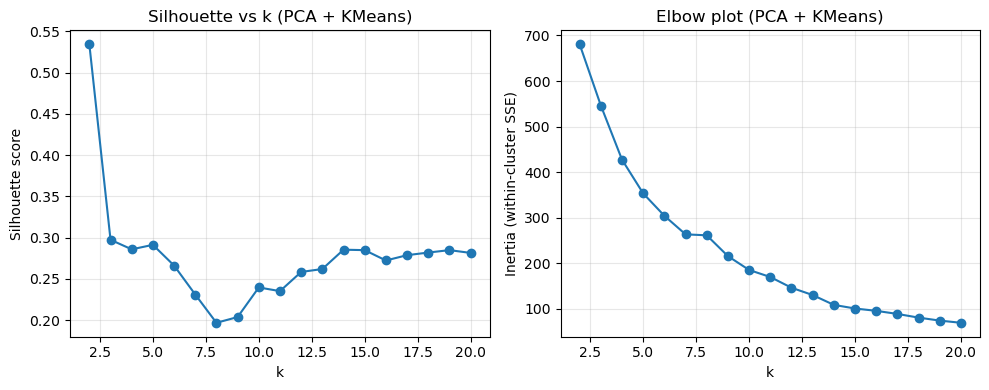

In [7]:
# Scan k for PCA+KMeans: silhouette scores and elbow plot
ks = range(2, 21)  # try k = 2..20
sil_scores = []
inertias = []


for k_scan in ks:
    km = KMeans(n_clusters=k_scan, random_state=0, n_init="auto")
    labels_k = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels_k)
    sil_scores.append(sil)
    inertias.append(km.inertia_)
    print(f"k={k_scan:2d}  silhouette={sil:.3f}  inertia={km.inertia_:.1f}")


plt.figure(figsize=(10, 4))


# Silhouette score vs k
plt.subplot(1, 2, 1)
plt.plot(list(ks), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (PCA + KMeans)")
plt.grid(True, alpha=0.3)


# Elbow plot: inertia vs k
plt.subplot(1, 2, 2)
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow plot (PCA + KMeans)")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [20]:
# Cluster farms in PCA space
k = 5  # number of clusters
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(X_pca)

# Store cluster labels (1..k)
df_smooth["profiles"] = labels + 1

In [21]:
# Optional: evaluate clustering quality
score = silhouette_score(X_pca, labels)
print(f"Silhouette score (PCA + KMeans, k={k}): {score:.3f}")

Silhouette score (PCA + KMeans, k=5): 0.291


In [32]:
# Define human‑readable names and fixed colors for each cluster.
# Edit these names/colors as you like. Make sure every cluster in df_features['cluster']
# has an entry here.

# Pre-EHF correction
# cluster_styles = {
#     1: {"name": "Daytime increase", "color": "#1f77b4"},
#     2: {"name": "Evening reduction", "color": "#ff7f0e"},
#     3: {"name": "Morning peak", "color": "#2ca02c"},
#     4: {"name": "No difference", "color": "#d62728"},
#     5: {"name": "All-day low", "color": "#9467bd"},
#     6: {"name": "Night-time increase", "color": "#8c564b"}
# }

# With smoothing
cluster_styles = {
    1: {"name": "All-day increase", "color": "#1f77b4"},
    2: {"name": "High-low", "color": "#ff7f0e"},
    3: {"name": "Severe low", "color": "#2ca02c"},
    4: {"name": "Marginal shift", "color": "#d62728"},
    5: {"name": "Night-time low", "color": "#9467bd"},
}

# # No smoothing
# cluster_styles = {
#     1: {"name": "All-day increase", "color": "#1f77b4"},
#     2: {"name": "High-low", "color": "#ff7f0e"},
#     3: {"name": "Severe low", "color": "#2ca02c"},
#     4: {"name": "Marginal shift", "color": "#d62728"},
#     5: {"name": "Night-time low", "color": "#9467bd"},
# }

missing_clusters = set(df_smooth["profiles"].unique()) - set(cluster_styles)
if missing_clusters:
    print("Warning: no style defined for clusters:", sorted(missing_clusters))

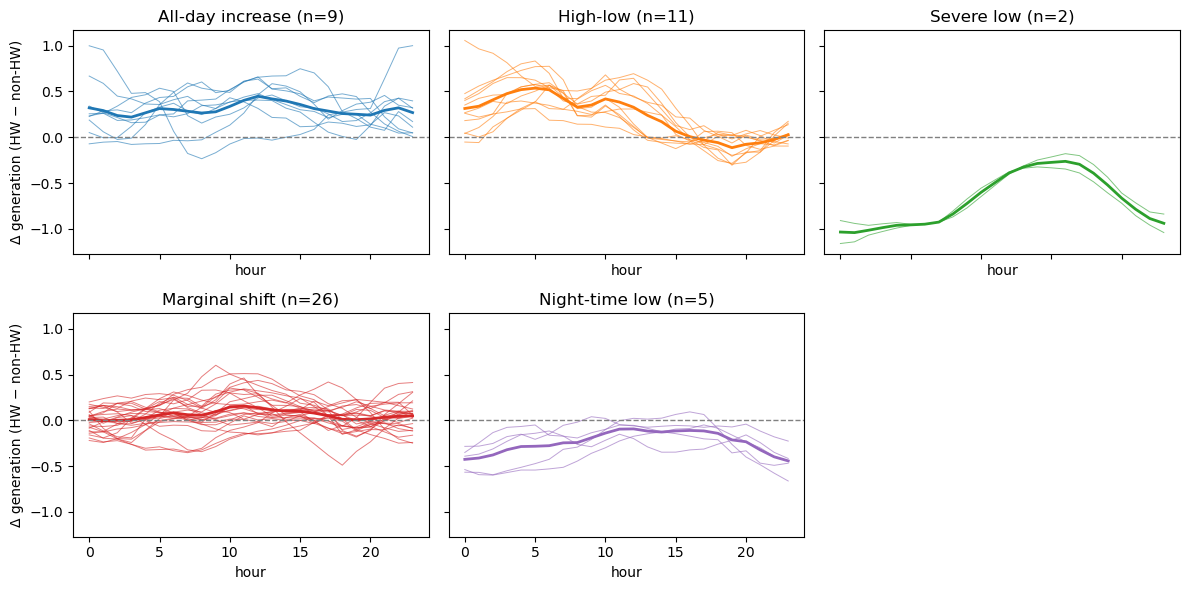

In [33]:
# sanity checks
if "profiles" not in df_smooth.columns:
    raise ValueError("df_smooth has no 'profiles' column; run the clustering cells first.")

clusters = sorted(df_smooth["profiles"].unique())
n_clusters = len(clusters)

# layout: up to 4 columns (change max_cols to taste)
max_cols = 3
cols = min(max_cols, n_clusters)
rows = math.ceil(n_clusters / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), sharex=True, sharey=True)
axes = axes.flatten() if n_clusters > 1 else [axes]

for ax_idx, cluster_label in enumerate(clusters):
    ax = axes[ax_idx]
    style = cluster_styles.get(int(cluster_label), {})
    color = style.get("color", "tab:blue")
    name = style.get("name", f"cluster {cluster_label}")
    cluster_curves = df_smooth[df_smooth["profiles"] == cluster_label].drop(columns="profiles")
    # convert hour column names to floats (assumes columns are numeric-like)
    hours = cluster_curves.columns.to_numpy().astype(float)

    # plot individual curves
    for _, row in cluster_curves.iterrows():
        ax.plot(hours, row.values, color=color, linewidth=0.7, alpha=0.6)

    # plot mean
    mean_curve = cluster_curves.mean(axis=0)
    ax.plot(hours, mean_curve, color=color, linewidth=2, label="mean")

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"{name} (n={len(cluster_curves)})")
    if ax_idx % cols == 0:
        ax.set_ylabel("Δ generation (HW − non‑HW)")
    ax.set_xlabel("hour")

# hide any unused subplots
for j in range(len(clusters), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [34]:
# Load coordinates
duid_coords = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/gen_info.csv")[["DUID", "lat", "lon"]]

df_smooth.index.name = 'DUID'
map_df = (
    df_smooth[["profiles"]]
    .rename_axis('DUID')              # ensures the index has name 'DUID'
    .reset_index()
    .merge(duid_coords, on="DUID", how="left")
)

# Merge cluster labels with coordinates
map_df = df_smooth[["profiles"]].reset_index().merge(duid_coords, on="DUID", how="left")

# Check for missing coordinates
missing = map_df[["lat", "lon"]].isna().any(axis=1).sum()
if missing:
    print(f"Warning: {missing} DUIDs have missing coordinates and will be skipped on the map")

# Keep only valid rows
valid = map_df.dropna(subset=["lat", "lon"]).copy()

# Number of clusters
n_clusters_found = int(valid["profiles"].nunique())
default_cmap = cm.get_cmap("tab20", max(1, n_clusters_found))

# Map center
center = [valid["lat"].mean(), valid["lon"].mean()]
m = folium.Map(location=center, zoom_start=6, tiles="CartoDB.Positron")

# Jitter scale (adjust if needed)
jitter_scale = 0.02  # degrees (~2km)

# Add points to the map with jitter
for _, row in valid.iterrows():
    cl = int(row["profiles"])
    style = cluster_styles.get(cl, {})
    if "color" in style:
        color_hex = style["color"]
    else:
        rgba = default_cmap(cl - 1 if cl > 0 else 0)
        color_hex = colors.rgb2hex(rgba[:3])

    # Add jitter
    lat_jitter = row["lat"] + np.random.uniform(-jitter_scale, jitter_scale)
    lon_jitter = row["lon"] + np.random.uniform(-jitter_scale, jitter_scale)

    popup_name = style.get("name", f"Profile {cl}")
    popup = folium.Popup(
        f"DUID: {row['DUID']}<br>Profile: {cl} ({popup_name})",
        parse_html=True,
    )
    folium.CircleMarker(
        location=[lat_jitter, lon_jitter],
        radius=5,
        color=color_hex,
        fill=True,
        fill_color=color_hex,
        fill_opacity=0.8,
        popup=popup
    ).add_to(m)

display(HTML(m._repr_html_()))

/jobfs/165589003.gadi-pbs/ipykernel_3884216/4203919055.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  default_cmap = cm.get_cmap("tab20", max(1, n_clusters_found))


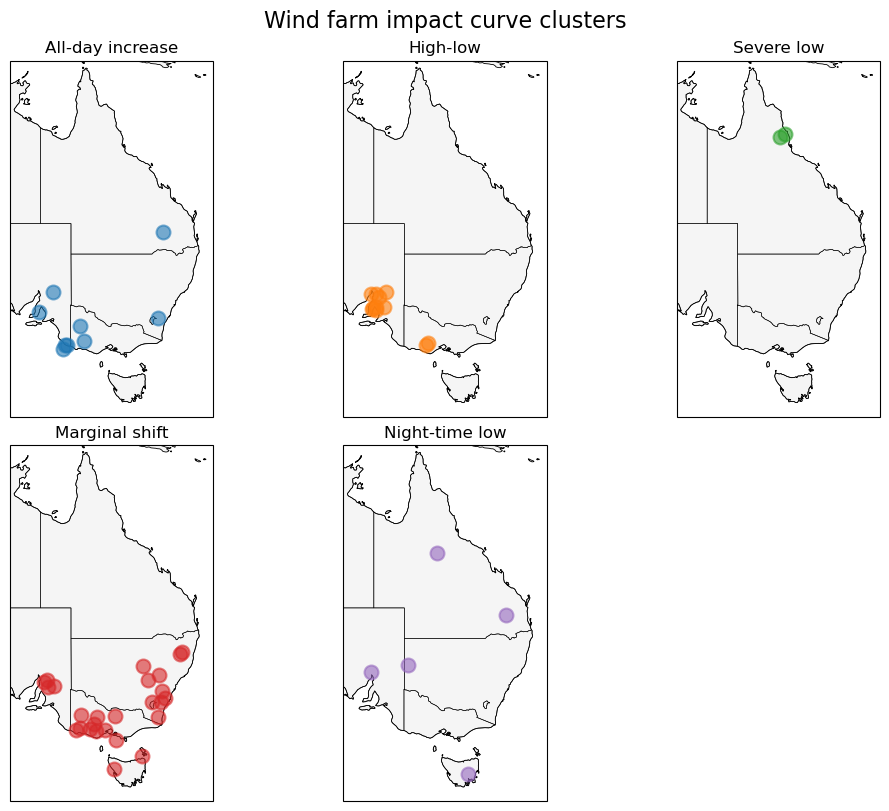

In [35]:
rng = np.random.default_rng(42)

jitter_lon = 0.5
jitter_lat = 0.5

valid_jitter = valid.copy()
valid_jitter["lon_j"] = valid_jitter["lon"] + rng.normal(0, jitter_lon, len(valid))
valid_jitter["lat_j"] = valid_jitter["lat"] + rng.normal(0, jitter_lat, len(valid))

clusters = sorted(valid_jitter["profiles"].unique())
n_clusters = len(clusters)

# --- facet layout ---
ncols = 3
nrows = math.ceil(n_clusters / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(10, 4 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

axes = np.atleast_1d(axes).ravel()

for ax, cl in zip(axes, clusters):
    subset = valid_jitter[valid_jitter["profiles"] == cl]
    style = cluster_styles.get(int(cl), {})

    # Map extent
    ax.set_extent([135, 155, -45, -10], crs=ccrs.PlateCarree())

    # Background
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.STATES, linewidth=0.4, zorder=2)

    # Points (single cluster only)
    ax.scatter(
        subset["lon_j"],
        subset["lat_j"],
        s=100,
        facecolors=style.get("color"),
        edgecolors=style.get("color"),
        linewidths=1.5,
        alpha=0.6,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

    ax.set_title(style.get("name", f"Cluster {cl}"))

# Remove unused axes if any
for ax in axes[len(clusters):]:
    ax.remove()

fig.suptitle("Wind farm impact curve clusters", fontsize=16)
plt.savefig(
    "/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_farms_profile_clusters_faceted.png",
    dpi=300,
)
plt.show()


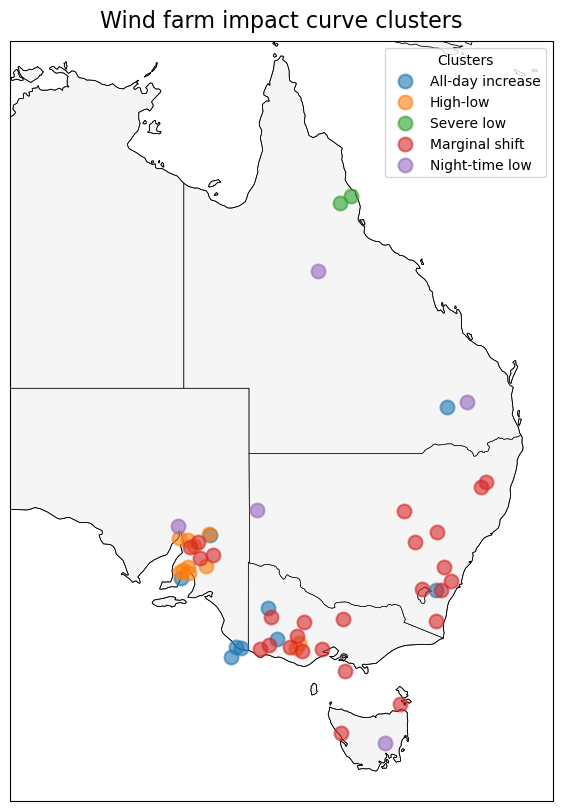

In [36]:
def plot_clusters_single_map(
    valid,
    cluster_styles,
    jitter_lon=0.5,
    jitter_lat=0.5,
    seed=42,
    extent=[130, 155, -45, -10],
    save_path=None,
):

    rng = np.random.default_rng(seed)

    # --- jitter points ---
    valid_jitter = valid.copy()
    valid_jitter["lon_j"] = valid_jitter["lon"] + rng.normal(0, jitter_lon, len(valid))
    valid_jitter["lat_j"] = valid_jitter["lat"] + rng.normal(0, jitter_lat, len(valid))

    clusters = sorted(valid_jitter["profiles"].unique())

    # --- create single map ---
    fig, ax = plt.subplots(
        figsize=(10, 8),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )

    # Map extent
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Background features
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.STATES, linewidth=0.4, zorder=2)

    # --- plot each cluster ---
    for cl in clusters:
        subset = valid_jitter[valid_jitter["profiles"] == cl]
        style = cluster_styles.get(int(cl), {})

        ax.scatter(
            subset["lon_j"],
            subset["lat_j"],
            s=100,
            facecolors=style.get("color"),
            edgecolors=style.get("color"),
            linewidths=1.5,
            alpha=0.6,
            transform=ccrs.PlateCarree(),
            label=style.get("name", f"Cluster {cl}"),
            zorder=3,
        )

    # Legend
    ax.legend(title="Clusters", loc="upper right")

    fig.suptitle("Wind farm impact curve clusters", fontsize=16)

    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

plot_clusters_single_map(
    valid,
    cluster_styles,
    save_path="/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_farms_profile_clusters_all.png",
)


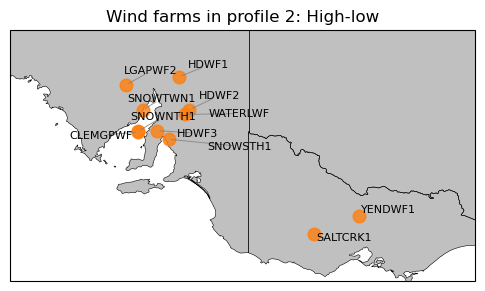

In [37]:
cluster_to_plot = 2  # change this to the profile number you want
subset = valid[valid["profiles"] == cluster_to_plot].copy()

if subset.empty:
    print(f"No DUIDs found for profile {cluster_to_plot}.")
else:
    # Get style info (name and colour) for this cluster
    style = cluster_styles.get(int(cluster_to_plot), {})
    color = style.get("color", "tab:blue")
    name = style.get("name", f"cluster {cluster_to_plot}")

    # --- ADD JITTER (up to 1 degree) ---
    jitter_deg = 1.0
    subset["lon_jitter"] = subset["lon"] + np.random.uniform(
        -jitter_deg, jitter_deg, size=len(subset)
    )
    subset["lat_jitter"] = subset["lat"] + np.random.uniform(
        -jitter_deg, jitter_deg, size=len(subset)
    )

    # Compute a slightly padded extent around the *jittered* points
    lon_min, lon_max = subset["lon_jitter"].min(), subset["lon_jitter"].max()
    lat_min, lat_max = subset["lat_jitter"].min(), subset["lat_jitter"].max()
    pad_lon = max(0.5, 0.5 * (lon_max - lon_min))
    pad_lat = max(0.5, 0.3 * (lat_max - lat_min))

    fig = plt.figure(figsize=(6, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min - pad_lon, lon_max + pad_lon,
                   lat_min - pad_lat, lat_max + pad_lat])

    # Background
    ax.add_feature(cfeature.LAND, facecolor="silver")
    ax.add_feature(cfeature.STATES, linewidth=0.4, zorder=2)

    # Plot points (jittered)
    ax.scatter(
        subset["lon_jitter"],
        subset["lat_jitter"],
        s=80,
        facecolors=color,
        edgecolors=color,
        linewidths=1.2,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

    # Label each DUID at its jittered point
    texts = []
    xs = subset["lon_jitter"].values
    ys = subset["lat_jitter"].values
    
    for x, y, duid in zip(xs, ys, subset["DUID"]):
        texts.append(
            ax.text(
                x,
                y,
                duid,
                fontsize=8,
                transform=ccrs.PlateCarree(),
                zorder=4,
            )
        )
    adjust_text(
        texts,
        x=xs,
        y=ys,
        ax=ax,
        expand_points=(10.0, 10.0),   # increase the point repulsion
        expand_text=(1.5, 1.5),     # text-text repulsion
        force_points=(5.0, 5.0),    # stronger push from points
        force_text=(0.5, 0.5),
        arrowprops=dict(
            arrowstyle="-",
            color="gray",
            lw=0.7,
            alpha=0.8,
            shrinkA=5,  # gap from label
            shrinkB=2,  # gap from point
        ),
    )
    ax.set_title(f"Wind farms in profile {cluster_to_plot}: {name}")
    plt.savefig(f"/g/data/ng72/ms5578/ID_HW_BARRA/data/output/wind_chapter/impact_clust_map/clust_{cluster_to_plot}.png", dpi=300)
    plt.show()


In [38]:
# Add profile name and color from cluster_styles
valid["profile_name"] = valid["profiles"].map(
    lambda cl: cluster_styles.get(int(cl), {}).get("name", f"cluster {int(cl)}")
)

valid["profile_color"] = valid["profiles"].map(
    lambda cl: cluster_styles.get(int(cl), {}).get("color", None)
)

# Save tidy long-format data
output_path = "/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_profile_clusters.csv"
valid.to_csv(output_path, index=False)

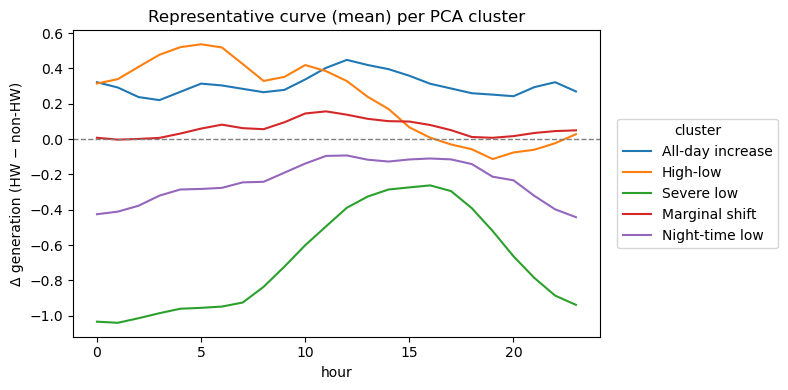

In [39]:
# Representative mean curve per PCA cluster (all clusters on one plot)

plt.figure(figsize=(8, 4))

hours = df_smooth.drop(columns="profiles").columns.to_numpy().astype(float)

for cl in sorted(df_smooth["profiles"].unique()):
    curves = df_smooth[df_smooth["profiles"] == cl].drop(columns="profiles")
    mean_curve = curves.mean(axis=0)
    style = cluster_styles.get(int(cl), {})
    color = style.get("color", None)
    label = style.get("name", f"cluster {cl}")
    plt.plot(hours, mean_curve, label=label, color=color)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.xlabel("hour")
plt.ylabel("Δ generation (HW − non‑HW)")
plt.title("Representative curve (mean) per PCA cluster")

plt.legend(
    title="cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()

plt.show()

In [30]:
reg_map = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_spatial_clusters.csv")[["DUID", "cluster"]]
# Combine region information with cluster labels
if "profiles" not in df_smooth.columns:
    raise ValueError("df_smooth has no 'profiles' column; run the clustering cells first.")

# df_smooth index is DUID; bring it into a column and merge with reg_map
spat_cluster = (
    df_smooth[["profiles"]]
    .reset_index()
    .rename(columns={"index": "DUID"})
    .merge(reg_map, on="DUID", how="left")
)

# Quick check of the mapping
display(spat_cluster.head())

# Plot number of DUIDs in each region
region_counts = (
    spat_cluster.groupby("cluster")["DUID"].nunique().sort_values(ascending=False)
)

,DUID,profiles,cluster
0,ARWF1,4,4
1,BALDHWF1,4,2
2,BLUFF1,4,0
3,BOCORWF1,4,5
4,BODWF1,4,5


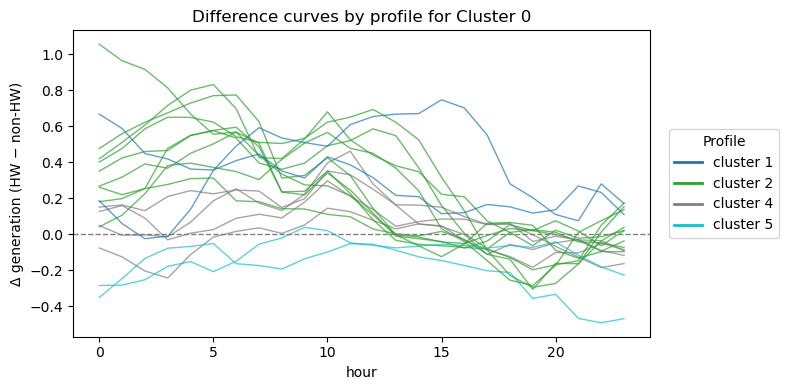

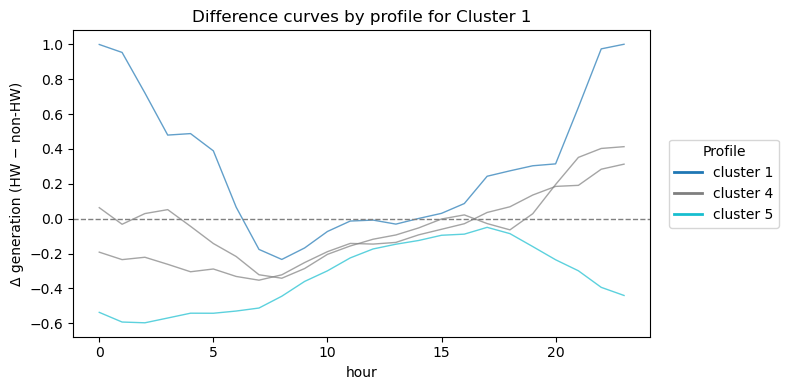

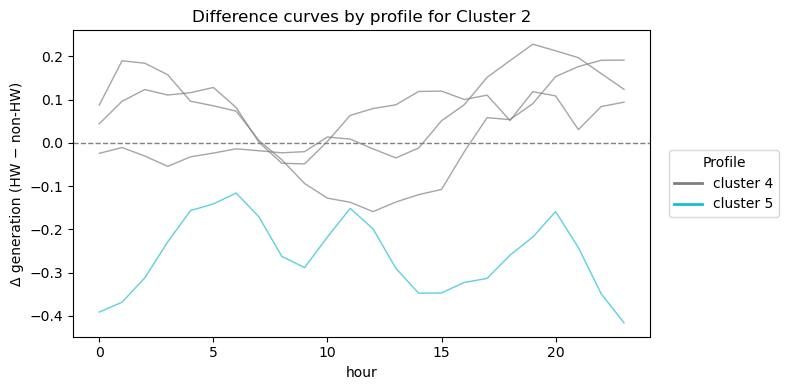

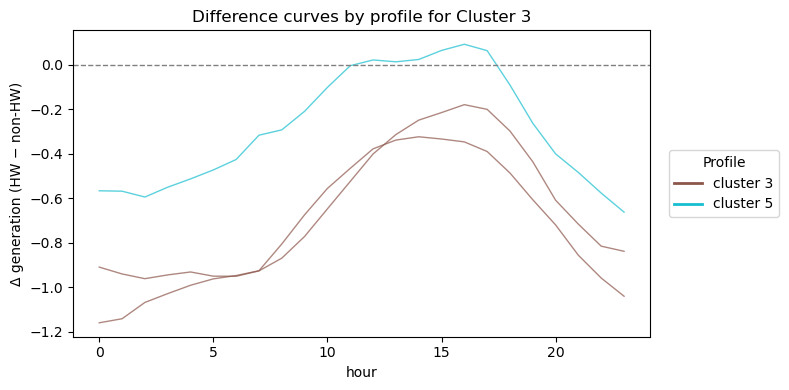

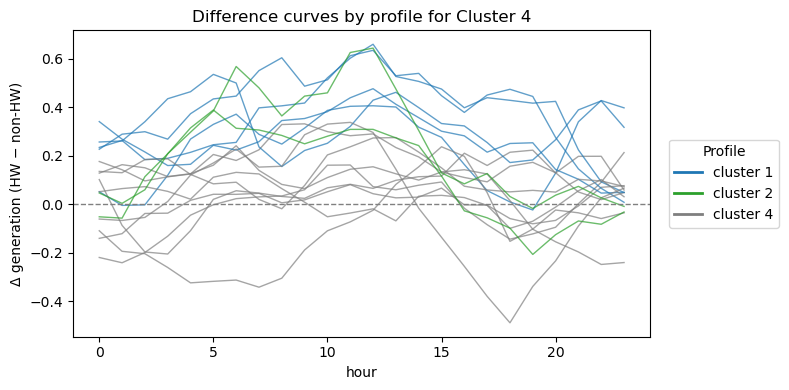

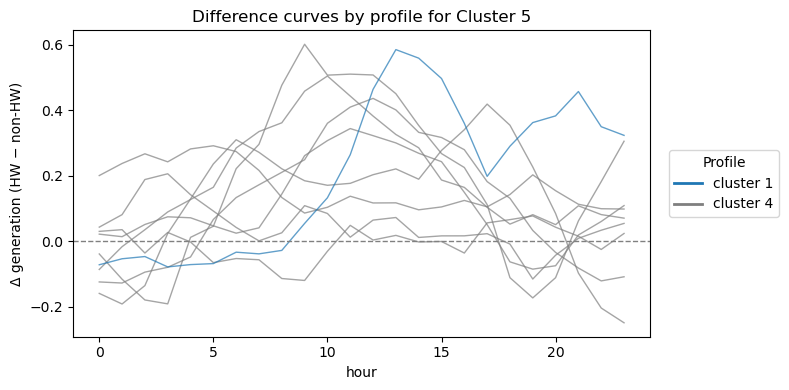

In [31]:
# Plot difference curves per region, coloured by cluster
from matplotlib.lines import Line2D

# Hours on the x-axis (assumes hour-like numeric column names)
hours = df_smooth.drop(columns="profiles").columns.to_numpy().astype(float)

# Global colour map for clusters
all_clusters = sorted(df_smooth["profiles"].unique())
cmap = plt.get_cmap("tab10", len(all_clusters))
cluster_to_color = {
    cl: cluster_styles.get(int(cl), {}).get("color", cmap(i))
    for i, cl in enumerate(all_clusters)
}

for region in sorted(spat_cluster["cluster"].dropna().unique()):
    duids = spat_cluster.loc[spat_cluster["cluster"] == region, "DUID"]
    if duids.empty:
        continue

    # Curves and clusters for this region
    curves = df_smooth.loc[duids].drop(columns="profiles")
    clusters_region = df_smooth.loc[duids, "profiles"]

    plt.figure(figsize=(8, 4))

    for duid in duids:
        curve = curves.loc[duid].values
        cl = int(clusters_region.loc[duid])
        color = cluster_to_color.get(cl, "grey")
        plt.plot(hours, curve, color=color, alpha=0.7, linewidth=1)

    # Legend showing clusters present in this region
    clusters_here = sorted(clusters_region.unique())
    legend_elems = [
        Line2D(
            [0],
            [0],
            color=cluster_to_color[int(cl)],
            lw=2,
            label=cluster_styles.get(int(cl), {}).get("name", f"cluster {int(cl)}"),
        )
        for cl in clusters_here
    ]

    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("hour")
    plt.ylabel("Δ generation (HW − non‑HW)")
    plt.title(f"Difference curves by profile for Cluster {region}")
    plt.legend(
        handles=legend_elems,
        title="Profile",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )
    plt.tight_layout()
    plt.show()

### 